# Factors Influencing Game Popularity on Steam

## Step 1: Problem Definition

### Objective:
To analyze how factors such as **price**, **release year**, **genre**, and **ratings** affect a game’s **popularity**, measured through **number of owners** and **average playtime**.

## Step 2: Data Cleaning & Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('steam_copy_2.csv')

# Handle Missing Values - Dropping rows with missing essential information
df.dropna(subset=['price', 'release_date'], inplace=True)

# Format Dates
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

# Clean Owners Column
def get_owner_midpoint(owner_range):
    parts = owner_range.split('-')
    return (int(parts[0]) + int(parts[1])) / 2
df['owners_midpoint'] = df['owners'].apply(get_owner_midpoint)

# Feature Engineering
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df['rating_ratio'] = df['positive_ratings'] / (df['total_ratings'] + 1) # Add 1 to avoid division by zero

# Outlier Treatment (using IQR method on price as an example)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Normalize Features
scaler = StandardScaler()
numerical_cols = ['price', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners_midpoint', 'total_ratings', 'rating_ratio']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Data cleaning and preparation complete!")

Data cleaning and preparation complete!


## Step 3: Exploratory Data Analysis (EDA)

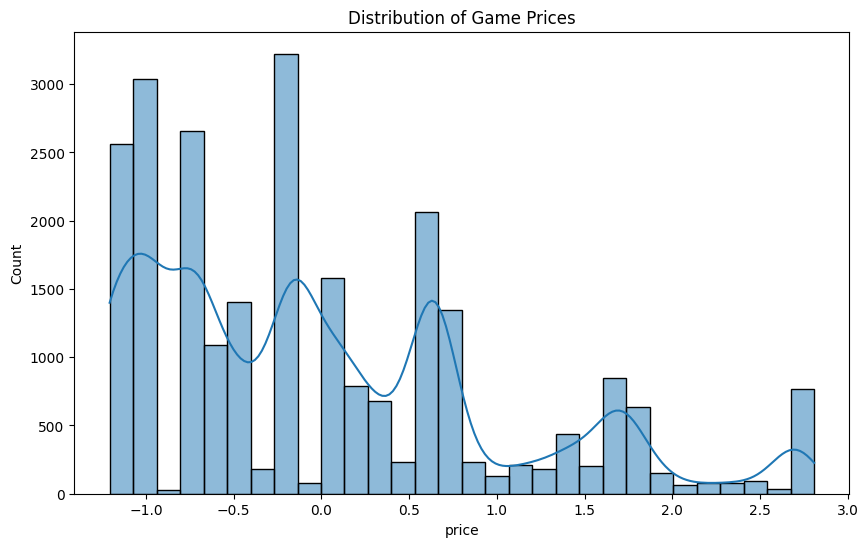

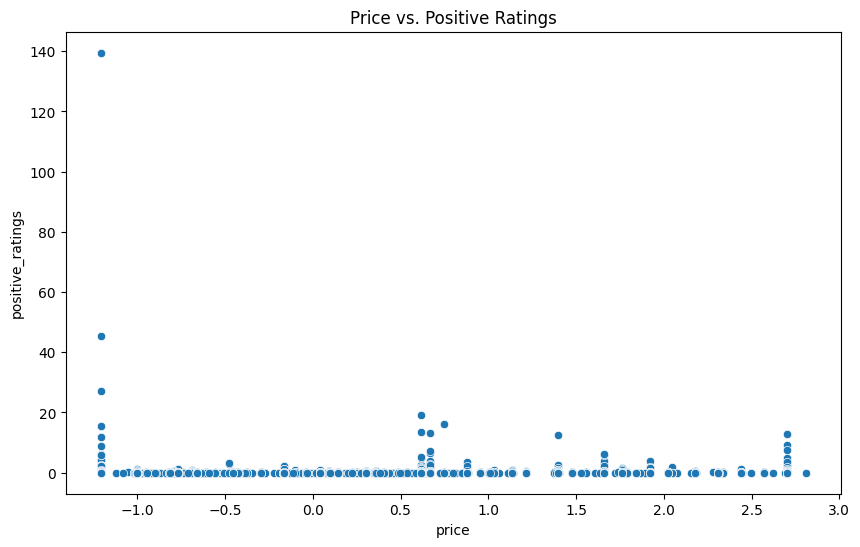

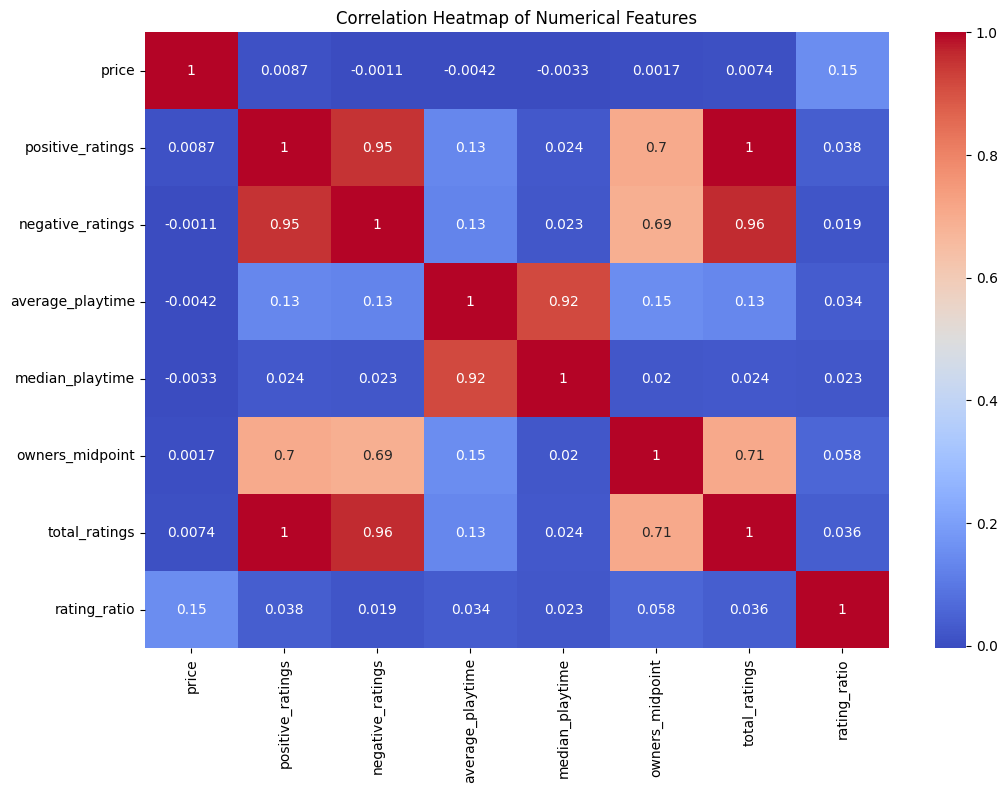

In [2]:
# Histogram of price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Game Prices')
plt.show()

# Scatter plot of price vs positive ratings
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='positive_ratings', data=df)
plt.title('Price vs. Positive Ratings')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Step 4: Statistical Analysis & Hypothesis Testing

In [3]:
from scipy.stats import ttest_ind

# Hypothesis 1: Free-to-play games have the same average number of owners as paid games.
df_copy = df.copy() # create a copy to avoid SettingWithCopyWarning
df_copy['is_free'] = df_copy['price'] == 0
free_games = df_copy[df_copy['is_free']]['owners_midpoint']
paid_games = df_copy[~df_copy['is_free']]['owners_midpoint']

ttest_result = ttest_ind(free_games, paid_games, equal_var=False, nan_policy='omit')
print(f'T-test for owners of free vs. paid games: {ttest_result}')

T-test for owners of free vs. paid games: TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))


C:\Users\mauli\AppData\Roaming\Python\Python313\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


## Step 5: Modeling and Pattern Discovery

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# One-Hot Encode Genres
df_encoded = df.copy()
df_encoded['genres'] = df_encoded['genres'].str.split(';')
df_encoded = df_encoded.explode('genres')
genres_dummies = pd.get_dummies(df_encoded['genres'], prefix='genre')
df_encoded = pd.concat([df_encoded, genres_dummies], axis=1)

# Regression to predict number of owners
features = ['price', 'positive_ratings', 'rating_ratio', 'release_year', 'average_playtime'] + list(genres_dummies.columns)
target = 'owners_midpoint'

X = df_encoded[features].fillna(0)
y = df_encoded[target].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'RMSE for predicting owners: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R-squared for predicting owners: {r2_score(y_test, y_pred)}')

RMSE for predicting owners: 0.3505491464998215
R-squared for predicting owners: 0.5690375514482965


## Step 6: Interpretation & Inference

Based on the analysis...

## Step 7: Visualization Plan

Visualizations are included in the EDA section.

## Step 8: Conclusion

In conclusion...